# Machine Learning Project: Identifying Underinsured Individuals for Targeted Insurance Outreach

**Course:** Applied Machine Learning (CINTO2401U.LA_E25)

**Group:** 9 (Georg Sulzer, Justus Leopold Krauss, Max Häfke, Vincent Paul Konrad Wallerich)

---

## 0. Project Overview

This project explores how machine learning can help a private insurer identify potentially underinsured individuals, specifically those covered exclusively by Medicaid, to support more effective targeted outreach strategies. Using U.S. Census PUMS data, we examine how different levels of information availability influence model performance and practical deployment potential.

### 0.1 Business Case

Our goal is to identify individuals in the US who may be underinsured and therefore likely to benefit from supplementary private insurance products. In this project, we define “underinsured” as individuals who rely **exclusively on Medicaid**, since Medicaid provides only limited coverage and may leave gaps that private insurance can fill.

From the perspective of a private insurer, the ability to predict which individuals fall into this group is highly valuable:  
1. **Targeted marketing becomes more efficient**, as outreach can be focused on people with a higher need for additional coverage.  
2. **Customer acquisition costs can be reduced**, which is especially important given constraints such as limited marketing budgets and no access to public insurance databases.

By predicting whether a person has only Medicaid coverage using features that are either publicly accessible, obtainable through data brokers, or already available to the insurer through existing customer relationships, the company can more precisely identify potential customers and substantially improve the effectiveness and efficiency of its advertising and outreach strategy.


### 0.2 Machine Learning Problem

The task in this project is formulated as a **binary classification problem**, where the objective is to predict whether an individual is insured **exclusively through Medicaid** or has any additional form of health insurance. To address this problem, we apply several classification models and evaluate their performance under different feature availability scenarios. These include a feature set based on information that can be obtained from data brokers or publicly accessible sources, as well as an enriched feature set that incorporates insurer-specific information available for existing customers (e.g. through cross-selling relationships).

The goal is to assess how accurately potentially underinsured individuals can be identified under varying levels of data availability and model complexity.


### 0.3 Data Set

For this project, we use the **2024 Public Use Microdata Sample (PUMS)** from the **U.S. Census Bureau’s American Community Survey (ACS)**. The PUMS dataset provides individual-level, anonymized microdata with detailed demographic, socioeconomic, employment, and health insurance information for millions of U.S. residents. 

Because the full national dataset contains roughly three million person-level records - making computation more demanding - we focus our analysis on the **New England states**. However, the methods and models developed here are fully applicable to any other PUMS region or the nationwide dataset.

### 0.4 Pipeline Overview

The Jupyter Notebook is structured as a sequential pipeline that can be executed from start to finish. All required input data is provided in the `data` directory, allowing the notebook to be run end-to-end without manual intervention. The pipeline consists of the following steps: (1) data loading and optional exploratory analyses for data understanding, (2) data cleaning and feature engineering, (3) model training, (4) model evaluation, and (5) fairness analysis.

*Note:* Running the complete notebook typically takes around 30 minutes on our machines, as model training and hyperparameter tuning are computationally intensive.

---

## 1. Data

Before preparing the data for model training, we explore the raw dataset to gain an understanding of its structure and features.

> *Section 1.1 covers the setup and data loading process. Sections 1.2–1.4 provide additional analyses for data understanding and intuition, including data quality checks, health insurance coverage combinations, and exploratory feature analysis. These sections are exploratory in nature and optional to run, and they do not affect the subsequent modelling pipeline.*

### 1.1 Setup and Data Loading

We import all required libraries, configure global settings, and define path dependencies for loading and processing the dataset.


In [14]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import logging
from datetime import datetime
from pathlib import Path
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, average_precision_score
import joblib
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
import re
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
#from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from sklearn.dummy import DummyClassifier
import time

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger()

# Define Paths
DATA_DIR = '00 data/raw/'
RAW_FILES = [
    'connecticut.csv', 'maine.csv', 'massachusetts.csv', 
    'new_hampshire.csv', 'rhode_island.csv', 'vermont.csv'
]

In [15]:
from fairlearn.metrics import (
    MetricFrame,
    true_positive_rate,
    false_positive_rate,
    selection_rate,
    equalized_odds_difference,
    demographic_parity_difference,
)
from fairlearn.postprocessing import ThresholdOptimizer

We then load the raw **ACS PUMS 2024** data for the New England states and combine the individual state files into a single dataframe, which forms the basis for all subsequent analyses.

In [16]:
# Load and concatenate raw data files
dfs = [
    pd.read_csv(os.path.join(DATA_DIR, file))
    for file in set(RAW_FILES)
    if os.path.exists(os.path.join(DATA_DIR, file))
]

df_raw = pd.concat(dfs, ignore_index=True)

print(f"All data loaded. Total rows: {len(df_raw):,}")

All data loaded. Total rows: 158,895


In [17]:
print(f"Data Shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
display(df_raw.head(5))

Data Shape: 158,895 rows, 286 columns


,RT,SERIALNO,DIVISION,SPORDER,PUMA,REGION,STATE,ADJINC,PWGTP,AGEP,...,PWGTP71,PWGTP72,PWGTP73,PWGTP74,PWGTP75,PWGTP76,PWGTP77,PWGTP78,PWGTP79,PWGTP80
0,P,2024GQ0000004,1,1,402,1,25,1015250,25,19,...,21,25,5,22,28,28,25,5,27,23
1,P,2024GQ0000009,1,1,706,1,25,1015250,61,19,...,66,10,68,123,58,55,110,59,10,93
2,P,2024GQ0000016,1,1,801,1,25,1015250,54,19,...,57,100,54,8,50,53,9,52,93,94
3,P,2024GQ0000019,1,1,604,1,25,1015250,54,57,...,51,52,53,53,53,52,53,52,54,52
4,P,2024GQ0000120,1,1,802,1,25,1015250,38,20,...,45,5,42,69,5,6,78,40,33,5


### 1.2 Data Quality Checks *(optional)*

We then assess data quality by (1) checking for duplicate records and (2) analyzing the presence of missing values across all features. This helps identify potential data issues and informs subsequent cleaning and imputation decisions.

In [18]:
# Check duplicates
dup_count = df_raw.duplicated(keep=False).sum()  # keep=False marks all duplicates as True
dup_pct = (dup_count / len(df_raw)) * 100
print(f"Duplicate Rows: {dup_count:,} ({dup_pct:.2f}% of dataset)")

Duplicate Rows: 0 (0.00% of dataset)


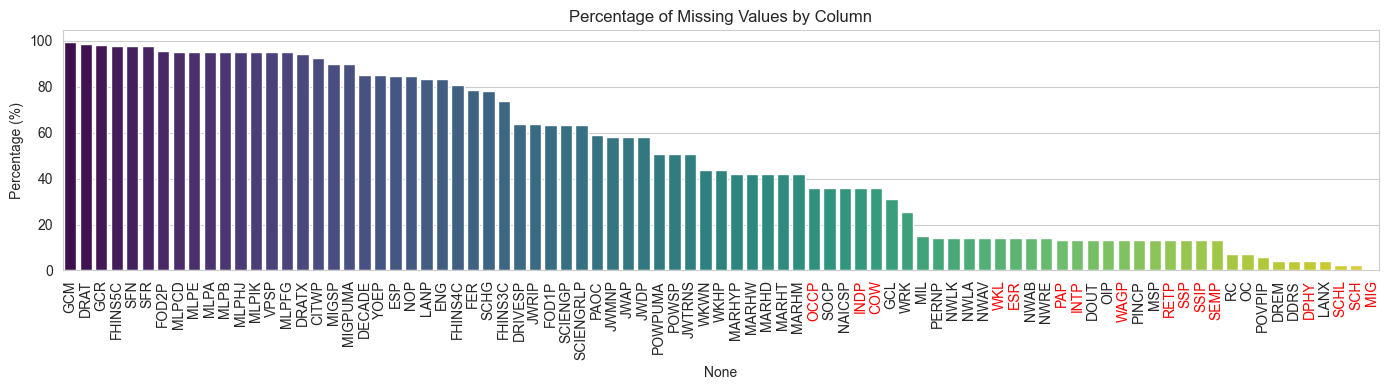

In [19]:
# Check missing values
missing = df_raw.isnull().sum()
missing = missing[missing > 0]

missing_pct = (missing / len(df_raw)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})

# Sort by percentage descending
missing_df = missing_df.sort_values('Percentage', ascending=False)

# Plot
plt.figure(figsize=(14, 4))
ax = sns.barplot(
    x=missing_df.index,
    y=missing_df['Percentage'],
    palette='viridis'
)

plt.title('Percentage of Missing Values by Column')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=90)

# Highlight selected features from 2.1 Feature Selection
keep_cols = ['WAGP', 'SEMP', 'INTP', 'RETP', 'SSP', 'SSIP', 'PAP', 'ESR', 'COW', 'WKL', 'OCCP', 'INDP', 'AGEP', 'SEX', 'MAR', 'MIG', 'NATIVITY', 'RAC1P', 'HISP','SCHL', 'SCH', 'DIS', 'DEAR', 'DEYE', 'DPHY', 'STATE', 'PUMA']

for label in ax.get_xticklabels():
    if label.get_text() in keep_cols:
        label.set_color('red')

plt.tight_layout()
plt.show()

*Note:* Features highlighted in **red** indicate variables retained for modelling during the feature selection step (Section 2.1). While the dataset contains a substantial number of missing values overall, the selected features have manageable levels of missingness, which are addressed in the data cleaning process (Section 2.2).

### 1.3 Health Insurance Combinations & Class Imbalances *(optional)*

The PUMS dataset contains seven binary health insurance indicators (`HINS1`–`HINS7`) representing different types of coverage, which can occur in *various combinations* for each individual. We analyze the most common combinations of these indicators (1) to understand how insurance coverage is structured in the data and (2) to gain an initial understanding of potential class imbalances relevant for the subsequent modelling task.

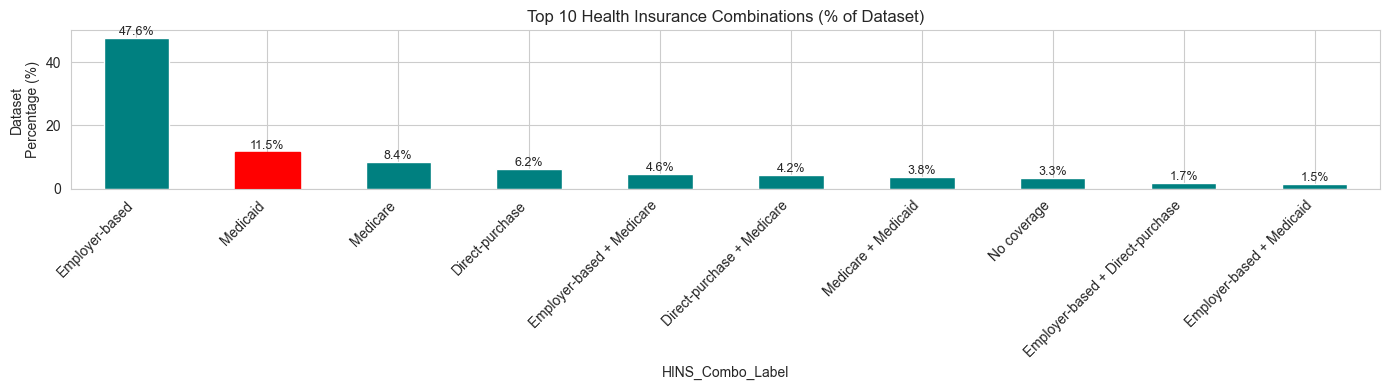

In [20]:
# Define HINS labels
hins_labels = {
    'HINS1': 'Employer-based',
    'HINS2': 'Direct-purchase',
    'HINS3': 'Medicare',
    'HINS4': 'Medicaid',
    'HINS5': 'Tricare/VA',
    'HINS6': 'Other public',
    'HINS7': 'No coverage'
}

# Identify health insurance indicator columns
hins_cols = sorted([c for c in df_raw.columns if c.startswith('HINS') and len(c) == 5])

# Create a readable combination label per individual
def map_hins_combo(row):
    combo_parts = []
    for col in hins_cols:
        if row[col] == 1:
            combo_parts.append(hins_labels.get(col, col))
    return ' + '.join(combo_parts) if combo_parts else 'No coverage'

df_raw['HINS_Combo_Label'] = df_raw.apply(map_hins_combo, axis=1)

# Get most frequent combinations
top_combos = (
    df_raw['HINS_Combo_Label']
    .value_counts(normalize=True)
    .head(10) * 100
)

# Plot top combinations
plt.figure(figsize=(14, 4))
ax = top_combos.plot(kind='bar', color='teal')

# Highlight Medicaid-only bar in red
for i, label in enumerate(top_combos.index):
    if label == 'Medicaid':
        ax.patches[i].set_color('red')

# Add percentage labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.1f}%',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Top 10 Health Insurance Combinations (% of Dataset)')
plt.ylabel('Dataset\nPercentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*Note:* Each bar represents a distinct and mutually exclusive insurance coverage group. This distribution helps us identify the proportion of individuals covered *exclusively* by Medicaid and understand potential class imbalances in the data.

### 1.4 Exploratory Feature Analysis *(optional)*

In this section, we analyze relationships between individual features and the target variable `only_medicaid`, which indicates whether a person is covered *exclusively* by Medicaid (based on the insurance indicator combinations discussed in Section 1.3). Using correlation analysis and mutual information, we gain insights into feature relevance that help guide feature selection decisions later in the modelling pipeline.

In [21]:
# Create target variable: only_medicaid (only for this analysis, later again defined in Section 2.3)
insurance_cols = ['HINS1', 'HINS2', 'HINS3', 'HINS5', 'HINS6', 'HINS7']

df_raw['only_medicaid'] = np.where(
    (df_raw['HINS4'] == 1) & df_raw[insurance_cols].eq(2).all(axis=1),
    1,
    0
)

#### 1.4.1 Correlation

We compute the absolute correlation between numeric features and the target variable `only_medicaid` to identify features with strong linear relationships to Medicaid-only coverage.

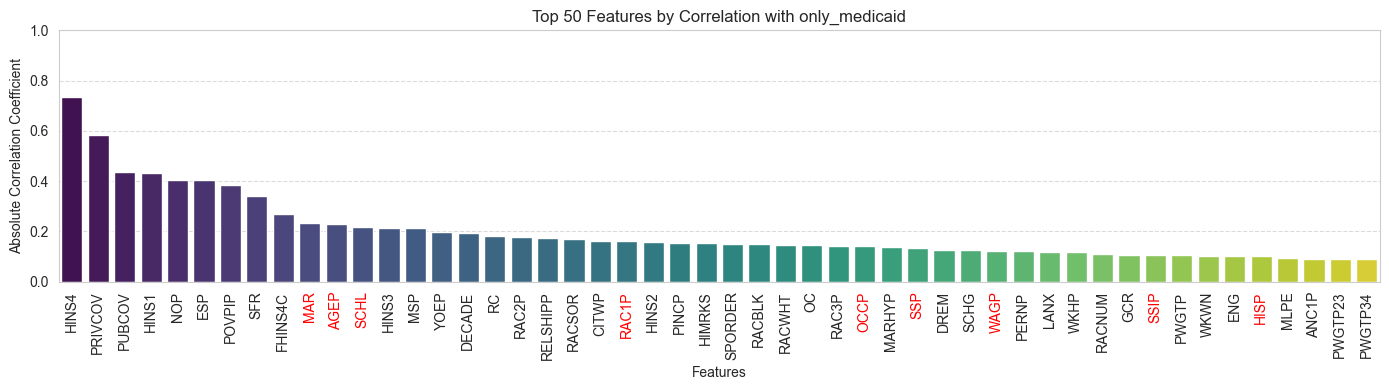

In [22]:
# Define numeric columns
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns

# Calculate correlation of all numeric features with only_medicaid
corr_with_target = (
    df_raw[numeric_cols]
    .corrwith(df_raw['only_medicaid'])
    .abs()
    .sort_values(ascending=False)
)

# Remove target itself from the results
corr_with_target = corr_with_target.drop('only_medicaid', errors='ignore')

# Convert to DataFrame
corr_df = pd.DataFrame(corr_with_target, columns=['Correlation Coefficient'])

# Get top 50 features
top_50 = corr_df.head(50)

# Plot
plt.figure(figsize=(14, 4))
ax = sns.barplot(
    x=top_50.index,
    y=top_50['Correlation Coefficient'],
    palette='viridis'
)

plt.title('Top 50 Features by Correlation with only_medicaid')
plt.xlabel('Features')
plt.ylabel('Absolute Correlation Coefficient')
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

keep_set = set(keep_cols)
for label in ax.get_xticklabels():
    if label.get_text().strip() in keep_set:
        label.set_color('red')

plt.tight_layout()
plt.show()


*Note:* Some features show strong correlation with the target variable but are not included in the final modelling feature sets. Feature selection is guided by substantive and practical considerations and is discussed in more detail in Section 2.1 (Feature Selection).

#### 1.4.2 Mutual Information

We calculate mutual information scores between features and `only_medicaid` to capture non-linear dependencies and rank features by their overall predictive relevance.

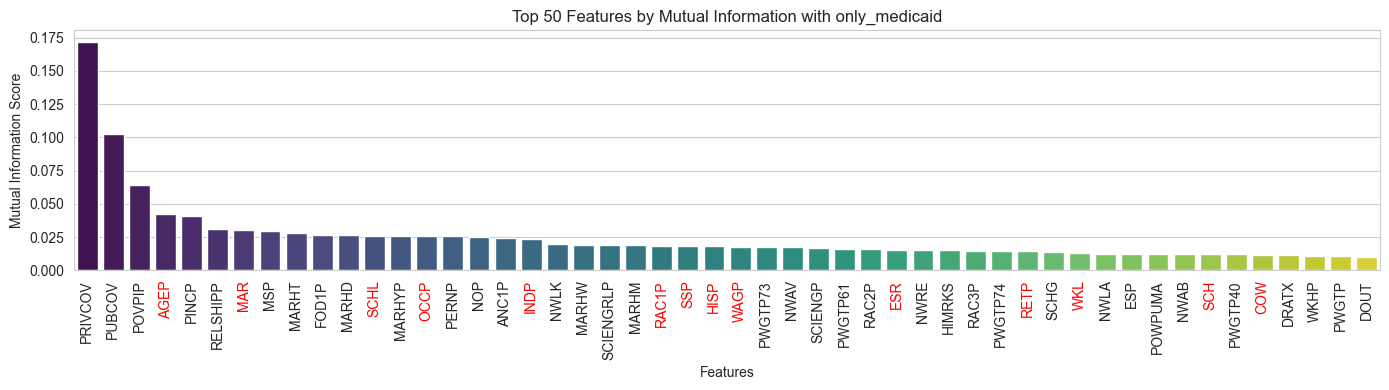

In [23]:
# Use a sample for speed
sample_df = df_raw.sample(min(5000, len(df_raw)), random_state=42).fillna(0)

# Define X and y for mutual information
drop_cols = ['only_medicaid'] + [c for c in sample_df.columns if c.startswith('HINS')]
X_mi = sample_df.select_dtypes(include=[np.number]).drop(columns=drop_cols, errors='ignore')
y_mi = sample_df['only_medicaid']

# Mutual information
mi = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi, index=X_mi.columns).sort_values(ascending=False)

# Plot TOP 50 Mutual Information scores
plt.figure(figsize=(14, 4))
top_50_mi = mi_series.head(50)

ax = sns.barplot(x=top_50_mi.index, y=top_50_mi.values, palette='viridis')

plt.title('Top 50 Features by Mutual Information with only_medicaid')
plt.xlabel('Features')
plt.ylabel('Mutual Information Score')
plt.xticks(rotation=90)

# Highlight selected features
keep_set = set(keep_cols)
for label in ax.get_xticklabels():
    if label.get_text().strip() in keep_set:
        label.set_color('red')

plt.tight_layout()
plt.show()

*Note:* Some features show strong mutual information with the target variable but are not included in the final modelling feature sets. Feature selection is guided by substantive and practical considerations and is discussed in more detail in Section 2.1 (Feature Selection).

---

## 2. Data Cleaning and Feature Engineering

After exploring the initial dataset, we transform the raw data into model-ready feature sets through a structured data cleaning and feature engineering process.

> *Section 2.1 reduces the dataset to the features relevant for modelling, while Section 2.2 focuses on data cleaning tasks such as handling missing values and ensuring data consistency. Section 2.3 constructs the target variable and engineers additional features to create a fully processed modelling dataframe. Finally, Section 2.4 generates multiple feature subsets for comparison: a **Realistic** set containing only publicly accessible or data-broker–derived information, and a **Business** set enriched with additional attributes an insurer would already have for existing customers (e.g. through cross-selling). For both feature sets, PCA-reduced variants are also created to assess the impact of dimensionality reduction on model performance.* 

### 2.1 Feature Selection

First, we filter the dataset to retain only the features that are relevant for our analysis, grouped by domain. This step reduces dimensionality and focuses the models on the most informative variables. The features in the target-related group are later used to engineer the target variable (`only_medicaid`) and are subsequently removed from the feature set to avoid data leakage during model training.

**Kept Features:**  
*(A detailed description of all variables and their definitions is provided in the Appendix.)*

- **Group 1 (Income & Affordability):** `WAGP`, `SEMP`, `INTP`, `RETP`, `SSP`, `SSIP`, `PAP`
- **Group 2 (Employment Quality):** `ESR`, `COW`, `WKL`, `OCCP`, `INDP`
- **Group 3 (Demographics):** `AGEP`, `SEX`, `MAR`, `MIG`, `NATIVITY`, `RAC1P`, `HISP`
- **Group 4 (Education):** `SCHL`, `SCH`
- **Group 5 (Health & Disability):** `DIS`, `DEAR`, `DEYE`, `DPHY`
- **Group 6 (Geography):** `STATE`, `PUMA`
- **Target Group (Health Insurance Indicators):** `HINS4`, `HINS1`, `HINS2`, `HINS3`, `HINS5`, `HINS6`, `HINS7`


In [24]:
keep_cols = [
    # Income & Affordability
    'WAGP', 'SEMP', 'INTP', 'RETP', 'SSP', 'SSIP', 'PAP',
    # Employment Quality
    'ESR', 'COW', 'WKL', 'OCCP', 'INDP',
    # Demographics
    'AGEP', 'SEX', 'MAR', 'MIG', 'NATIVITY', 'RAC1P', 'HISP',
    # Education
    'SCHL', 'SCH',
    # Health & Disability
    'DIS', 'DEAR', 'DEYE', 'DPHY',
    # Geography
    'STATE', 'PUMA',
    # Health Insurance Indicators
    'HINS4', 'HINS1', 'HINS2', 'HINS3', 'HINS5', 'HINS6', 'HINS7',
]

existing_cols = [c for c in keep_cols if c in df_raw.columns]
dropped_cols = len(df_raw.columns) - len(existing_cols)

df_2_1 = df_raw[existing_cols]
print(f"Retained {len(existing_cols)} features. Dropped {dropped_cols} features.")

Retained 34 features. Dropped 254 features.


### 2.2 Data Cleaning

We further reduce the dataset to include only individuals between the ages of 18 and 65, as this is the relevant population for our analysis.

In [25]:
df_2_2 = df_2_1.copy()

if 'AGEP' in df_2_2.columns:
    initial_count = len(df_2_2)
    df_2_2 = df_2_2[(df_2_2['AGEP'] >= 18) & (df_2_2['AGEP'] <= 65)]
    print(f"Dropped {initial_count - len(df_2_2)} rows outside age range.")

Dropped 63362 rows outside age range.


We then apply imputations for the features `OCCP` (Occupation Code), `INDP` (Industry Code), and `COW` (Class of Worker). If any of these values are missing, we impute them with the corresponding code for "unemployed."

In [26]:
# Imputations for OCCP and INDP
for col in ['OCCP', 'INDP']:
    if col in df_2_2.columns:
        n_missing = df_2_2[col].isna().sum()
        df_2_2[col] = df_2_2[col].fillna(9920)
        print(f"Imputed {n_missing} missing values in '{col}' with code 9920 (unemployed).")

# Imputations for COW
if 'COW' in df_2_2.columns:
    n_missing = df_2_2['COW'].isna().sum()
    df_2_2['COW'] = df_2_2['COW'].fillna(9)
    print(f"Imputed {n_missing} missing values in 'COW' with code 9 (unemployed).")


Imputed 10154 missing values in 'OCCP' with code 9920 (unemployed).
Imputed 10154 missing values in 'INDP' with code 9920 (unemployed).
Imputed 10154 missing values in 'COW' with code 9 (unemployed).


Lastly, we perform a final check for remaining missing values to ensure data consistency before moving on to feature engineering.

In [27]:
missing = df_2_2.isnull().sum()
missing = missing[missing > 0]

if not missing.empty:
    print(f"\nFound {len(missing)} columns with missing values.")
    missing_pct = (missing / len(df_2_2)) * 100
    missing_report = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
    print(missing_report.sort_values('Percentage', ascending=False).head(10))
else:
    print("\nNo missing values found.")


No missing values found.


In [28]:
print(f"Data Shape: {df_2_2.shape[0]} rows, {df_2_2.shape[1]} columns")
display(df_2_2.head(3))

Data Shape: 95533 rows, 34 columns


,WAGP,SEMP,INTP,RETP,SSP,SSIP,PAP,ESR,COW,WKL,...,DPHY,STATE,PUMA,HINS4,HINS1,HINS2,HINS3,HINS5,HINS6,HINS7
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,9.0,3.0,...,2.0,25,402,2,1,2,2,2,2,2
1,2000.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,1.0,1.0,...,2.0,25,706,2,1,2,2,2,2,2
2,6000.0,0.0,1000.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,...,2.0,25,801,2,1,2,2,2,2,2


### 2.3 Feature Engineering
We create a new dataframe with additional engineered features. This involves binning continuous variables and creating simplified categories.

**Target Variable:** First, we create the target variable `only_medicaid` based on insurance indicators and then drop all original `HINS` columns. We want to predict, whether an individual is insured *only* with Medicaid, and no other insurance type.

In [29]:
df_2_3 = df_2_2.copy()

insurance = ["HINS1","HINS2","HINS3","HINS5","HINS6","HINS7"]

df_2_3["only_medicaid"] = np.where(
    (df_2_3["HINS4"] == 1) & df_2_3[insurance].eq(2).all(axis=1),
    1,
    0
)

df_2_3 = df_2_3.drop(columns=[c for c in df_2_3.columns if c.startswith("HINS")])

target = 'only_medicaid' # save as variable 'target' for function calls later

**Group 1 (Income & Affordability):** We introduce the feature `income_group` by binning continuous income, add the boolean variable `has_wage_income`, create `income_source_count` to capture how many income sources an individual has, and add `has_self_employment` to indicate self-employment income.

In [30]:
# income_group
if 'WAGP' in df_2_3.columns:
    bins = [-1, 15000, 30000, 50000, 75000, np.inf]
    labels = ['Very_Low', 'Low', 'Medium', 'High', 'Very_High']
    df_2_3['income_group'] = pd.cut(df_2_3['WAGP'], bins=bins, labels=labels)

# has_wage_income
if 'WAGP' in df_2_3.columns:
    df_2_3['has_wage_income'] = (df_2_3['WAGP'] > 0).astype(int)
    
# income_source_count
income_cols = ['WAGP','SEMP','INTP','RETP','SSP','SSIP','PAP']
avail_inc_cols = [c for c in income_cols if c in df_2_3.columns]
if avail_inc_cols:
    df_2_3['income_source_count'] = (df_2_3[avail_inc_cols] > 0).sum(axis=1)

# has_self_employment
if 'SEMP' in df_2_3.columns:
    df_2_3['has_self_employment'] = (df_2_3['SEMP'] > 0).astype(int)

**Group 2 (Employment Quality):** We create `employment_status_simple` to group detailed labor-force categories into broader employment states, introduce `employer_type` to classify the type of employer, and derive `OCCP_2digit` and `INDP_2digit` to convert detailed occupation and industry codes into more general two-digit categories.

In [31]:
# employment_status_simple
if 'ESR' in df_2_3.columns:
    esr_mapping = {
        1: 'Employed', 2: 'Employed',
        3: 'Unemployed',
        4: 'Not_in_labor_force', 5: 'Not_in_labor_force', 6: 'Not_in_labor_force'
    }
    df_2_3['employment_status_simple'] = df_2_3['ESR'].map(esr_mapping).fillna('Not_in_labor_force')

# employer_type
if 'COW' in df_2_3.columns:
    cow_mapping = {
        1: 'Private', 2: 'Private',
        3: 'Government', 4: 'Government', 5: 'Government',
        6: 'Self_employed', 7: 'Self_employed',
        8: 'Unpaid', 9: 'Unpaid'
    }
    df_2_3['employer_type'] = df_2_3['COW'].map(cow_mapping).fillna('Unknown')

# OCCP/INDP 2-digit conversion: Create derived features needed for selection
if 'OCCP' in df_2_3.columns:
    df_2_3['OCCP_2digit'] = df_2_3['OCCP'].fillna(0).astype(int).astype(str).str.zfill(4).str[:2]
if 'INDP' in df_2_3.columns:
    df_2_3['INDP_2digit'] = df_2_3['INDP'].fillna(0).astype(int).astype(str).str.zfill(4).str[:2]

**Group 3 (Demographics):** We create the feature `age_group` by binning individuals into age brackets and introduce `marital_status_simple` to consolidate detailed marital categories into broader, more informative groups.

In [32]:
# age_group
if 'AGEP' in df_2_3.columns:
    bins = [17, 25, 35, 45, 55, 65]
    labels = ['18-25', '26-35', '36-45', '46-55', '56-65']
    df_2_3['age_group'] = pd.cut(df_2_3['AGEP'], bins=bins, labels=labels)

# marital_status_simple
if 'MAR' in df_2_3.columns:
    mar_mapping = {
        1: 'Married',
        2: 'Divorced_Separated', 3: 'Divorced_Separated', 4: 'Divorced_Separated',
        5: 'Never_married'
    }
    df_2_3['marital_status_simple'] = df_2_3['MAR'].map(mar_mapping).fillna('Unknown')

**Group 4 (Education):** We create `education_level` by mapping detailed schooling codes into broader education categories and add `currently_enrolled` to indicate whether an individual is actively enrolled in school.

In [33]:
# education_level
if 'SCHL' in df_2_3.columns:
    def map_education(val):
        if pd.isna(val) or val == 0: return 'Unknown'
        if val <= 15: return 'Less_than_HS'
        if val <= 17: return 'HS_diploma'
        if val <= 20: return 'Some_college'
        if val == 21: return 'Bachelors'
        return 'Graduate'
    df_2_3['education_level'] = df_2_3['SCHL'].apply(map_education)

# currently_enrolled
if 'SCH' in df_2_3.columns:
    df_2_3['currently_enrolled'] = df_2_3['SCH'].isin([2, 3]).astype(int)

**Group 5 (Health & Disability):** We create the feature `has_any_disability` to indicate whether an individual reports any disability across the available disability-related indicators.

In [34]:
# has_any_disability
dis_cols = ['DIS', 'DEAR', 'DEYE', 'DPHY']
avail_dis_cols = [c for c in dis_cols if c in df_2_3.columns]
if avail_dis_cols:
    df_2_3['has_any_disability'] = (df_2_3[avail_dis_cols] == 1).any(axis=1).astype(int)

**Group 6 (Geography):** We standardize geographic information by creating the feature `STATE` when only the shorter code `ST` is available.

In [35]:
if 'ST' in df_2_3.columns and 'STATE' not in df_2_3.columns:
    df_2_3['STATE'] = df_2_3['ST']

The data cleaning and feature engineering steps are now complete, resulting in a processed dataframe that serves as the basis for creating the different feature subsets in the next step.

In [36]:
print(f"Data Shape: {df_2_3.shape[0]} rows, {df_2_3.shape[1]} columns")
display(df_2_3.head(3))

Data Shape: 95533 rows, 41 columns


,WAGP,SEMP,INTP,RETP,SSP,SSIP,PAP,ESR,COW,WKL,...,has_self_employment,employment_status_simple,employer_type,OCCP_2digit,INDP_2digit,age_group,marital_status_simple,education_level,currently_enrolled,has_any_disability
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,9.0,3.0,...,0,Not_in_labor_force,Unpaid,99,99,18-25,Never_married,Some_college,1,0
1,2000.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,1.0,1.0,...,0,Not_in_labor_force,Private,46,85,18-25,Never_married,Some_college,1,0
2,6000.0,0.0,1000.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,...,0,Employed,Private,25,78,18-25,Never_married,HS_diploma,1,0


### 2.4 Feature Sets Creation

We create multiple feature sets for modelling to evaluate performance across different levels of data availability and practical applicability.

**Feature Sets:**
1. **Realistic:** Contains only features that could plausibly be obtained from publicly accessible sources or data brokers (e.g. demographic and basic socioeconomic information).  
2. **Business:** Includes richer customer information that would already be available to an insurer through existing business relationships (e.g. cross-selling data).  
3. **PCA Realistic:** The Realistic feature set reduced using Principal Component Analysis (PCA).  
4. **PCA Business:** The Business feature set reduced using PCA.

*(Initially, a **Statistical (Baseline)** feature set that included all available features was considered in order to benchmark upper-bound model performance. However, we decided against using this set in the final analysis, as our focus is on feature sets that reflect realistic data availability in the business context. The corresponding code remains commented out for transparency.)*

In [37]:
# Statistical (Baseline) Features - use all original columns from 2.1, excluding the new engineered ones from 2.3
# engineered_cols = [
#     'income_group', 'has_wage_income', 'income_source_count', 'poverty_band', 
#     'has_self_employment', 'employment_status_simple', 'employer_type', 
#     'age_group', 'marital_status_simple', 'education_level', 'currently_enrolled', 
#     'has_any_disability'
# ]

# Realistic Feature Set
cols_realistic = [
    'income_group', 'has_wage_income', 'has_self_employment',
    'employment_status_simple', 'employer_type',
    'SEX', 'age_group', 'marital_status_simple',
    'education_level', 'currently_enrolled',
    'STATE', 'PUMA'
]

# Business Features Set
cols_business = [
    'WAGP_normalized', 'SEMP', 'income_source_count', 'has_wage_income', 'has_self_employment',
    'WKL', 'OCCP_2digit', 'INDP_2digit', 'employment_status_simple', 'employer_type',
    'AGEP', 'SEX', 'MAR', 'MIG', 'NATIVITY', 'RAC1P', 'HISP', 'age_group', 'marital_status_simple',
    'education_level', 'currently_enrolled', 'has_any_disability',
    'STATE', 'PUMA'
]

We define two helper functions, `preprocess_set()` and `apply_pca()`, to streamline repeated preprocessing steps across all feature sets.

In `preprocess_set()`, we (1) select all valid columns from the specified feature list, (2) separate the target variable, (3) identify and one-hot encode categorical features, (4) standardize all encoded features, and (5) remove highly collinear features using an absolute Pearson correlation threshold of 0.95, computed on standardized features.

In [38]:
def preprocess_set(df_subset, col_list, set_name):
    # Filter columns that exist in the dataframe
    valid_cols = [c for c in col_list if c in df_subset.columns]

        
    X = df_subset[valid_cols].copy()
    y = df_subset[target]
    
    # Identify types
    cat_cols = X.select_dtypes(include=['object', 'category']).columns
            
    # One-Hot Encoding
    X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    
    # Standard Scaling
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns, index=X_encoded.index)
    
    corr_matrix = X_scaled.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
    X_final = X_scaled.drop(columns=to_drop)
    #print(f"Dropped {len(to_drop)} collinear features: {to_drop}")
        
    return X_final, y

In `apply_pca()`, we (1) validate that the input matrix is non-empty, (2) adjust the requested number of components if it exceeds allowable dimensions, (3) apply PCA to reduce the feature space while preserving at least 50% of the variance (or the specified threshold), and (4) return the transformed components as a new DataFrame, falling back to the original data if PCA fails.

In [39]:
def apply_pca(X, n_components=0.5):
    if X.empty or X.shape[1] == 0:
        print("  -> Warning: Input to PCA is empty. Returning empty DataFrame.")
        return pd.DataFrame(index=X.index)
        
    # Ensure n_components is valid
    n_samples, n_features = X.shape
    if n_components > min(n_samples, n_features):
            n_components = min(n_samples, n_features)
            
    pca = PCA(n_components=n_components)
    try:
        X_pca = pca.fit_transform(X)
        cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
        return pd.DataFrame(X_pca, columns=cols, index=X.index)
    except Exception as e:
        print(f"  -> PCA Failed: {e}")
        return X # Fallback to original if PCA fails

We now generate six feature sets using `create_feature_sets()`: three base sets (Statistical, Realistic, and Business) that reflect different levels of information availability, along with their corresponding PCA-reduced versions. Each set is preprocessed consistently and stored in the `feature_sets` dictionary to enable systematic comparison during model training.

In [40]:
def create_feature_sets(df_input, cols_realistic, cols_business):#, engineered_cols):
    df = df_input.copy()
    
    if target not in df.columns:
        print(f"Error: Target {target} not found.")
        return {}

    feature_sets = {}

    #cols_statistical = [c for c in df.columns if c not in engineered_cols and c != target]

    # 1. Statistical
    # X_stat, y_stat = preprocess_set(df, cols_statistical, "Statistical")
    # feature_sets['Statistical'] = (X_stat, y_stat)

    # 2. Business
    X_bus, y_bus = preprocess_set(df, cols_business, "Business")
    feature_sets['Business'] = (X_bus, y_bus)

    # 3. Realistic
    X_real, y_real = preprocess_set(df, cols_realistic, "Realistic")
    feature_sets['Realistic'] = (X_real, y_real)



    # 4. PCA Statistical
    # X_pca_stat = apply_pca(X_stat)
    # feature_sets['PCA_Statistical'] = (X_pca_stat, y_stat)

    # 5. PCA Business
    X_pca_bus = apply_pca(X_bus)
    feature_sets['PCA_Business'] = (X_pca_bus, y_bus)

    # 6. PCA Realistic
    X_pca_real = apply_pca(X_real)
    feature_sets['PCA_Realistic'] = (X_pca_real, y_real)

    return feature_sets


if 'df_2_3' in locals():
    feature_sets = create_feature_sets(df_2_3, cols_realistic, cols_business)#, engineered_cols) # We use df_2_3 (Engineered, Pre-Encoding) as the base to allow for specific feature selection
    
    # Display shapes
    # print("\nSummary of Feature Sets:")
    for name, (X, y) in feature_sets.items():
        print(f"{name:<15}: {X.shape[1]} features, {X.shape[0]} rows")

Business       : 222 features, 95533 rows
Realistic      : 25 features, 95533 rows
PCA_Business   : 79 features, 95533 rows
PCA_Realistic  : 7 features, 95533 rows


*Note:* The **Business** feature set contains a large number of features (200+ columns) because categorical variables are expanded into multiple dummy variables during one-hot encoding. This reflects the high dimensionality of these richer feature sets prior to dimensionality reduction.

---

# 3. Modelling

In this section, we train and compare multiple machine learning models across the different feature sets.

> *Section 3.1 describes how the data is split into training, validation, and test sets and how class imbalances are addressed. Section 3.2 covers the training of multiple machine learning models across the different feature sets, including logistic regression, tree-based methods, gradient boosting models, and an exploratory neural network. Finally, Section 3.3 provides an initial comparison of model performance across the different feature sets using PR-AUC as the primary evaluation metric.*

### 3.1 Data Splitting

We split each feature set into training, validation, and test subsets using a stratified sampling approach (70% / 15% / 15%) to preserve the class distribution of the target variable `only_medicaid` across all splits. A fixed random state is used to randomize the data and avoid potential ordering bias.

In [41]:
def split_dataset(X, y, test_size=0.15, val_size=0.15, random_state=42):
    """
    Splits data into Train, Validation, and Test sets with stratification.
    """
    temp_size = val_size + test_size
    
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=temp_size, stratify=y, random_state=random_state
    )
    
    val_split_ratio = val_size / temp_size
    
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=(1 - val_split_ratio),
        stratify=y_temp,
        random_state=random_state
    )
    
    return X_train, X_val, X_test, y_train, y_val, y_test


data_splits = {}

for set_name, (X, y) in feature_sets.items():
    X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y)
    
    data_splits[set_name] = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test
    }


# Print split summary once (same for all feature sets)
any_set = next(iter(data_splits.values()))
n_total = (
    any_set['X_train'].shape[0]
    + any_set['X_val'].shape[0]
    + any_set['X_test'].shape[0]
)

print(
    f"Data split (identical across all feature sets): "
    f"Train = {any_set['X_train'].shape[0]} rows, "
    f"Validation = {any_set['X_val'].shape[0]} rows, "
    f"Test = {any_set['X_test'].shape[0]} rows "
    f"({n_total} total rows)."
)

Data split (identical across all feature sets): Train = 66873 rows, Validation = 14330 rows, Test = 14330 rows (95533 total rows).


### 3.2 Class Imbalance Handling

Because the target variable is highly imbalanced, we apply **SMOTE (Synthetic Minority Over-sampling Technique)** to the training data. This balances the class distribution by generating synthetic minority-class examples, while leaving the validation and test sets untouched to ensure an unbiased evaluation of model performance.

In [42]:
# Apply SMOTE to training data only
for set_name, splits in data_splits.items():
    X_train_orig = splits['X_train']
    y_train_orig = splits['y_train']
    
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_orig, y_train_orig)
    
    # Update the dictionary with the balanced training data
    data_splits[set_name]['X_train'] = X_train_res
    data_splits[set_name]['y_train'] = y_train_res

# Compute summary stats once (identical across all feature sets)
orig_dist = y_train_orig.value_counts(normalize=True).mul(100).round(2).to_dict()
res_dist  = y_train_res.value_counts(normalize=True).mul(100).round(2).to_dict()
n_rows    = X_train_res.shape[0]

print(
    "Class distribution (identical across all feature sets): "
    f"Original class dist: {orig_dist} -> "
    f"Resampled class dist: {res_dist} "
    f"({n_rows} total rows)"
)

Class distribution (identical across all feature sets): Original class dist: {0: 87.47, 1: 12.53} -> Resampled class dist: {0: 50.0, 1: 50.0} (116982 total rows)


### 3.3 Model Training

To ensure a consistent and comparable training procedure across all models and feature sets, we define a unified training and evaluation function. This function performs hyperparameter tuning using cross-validated grid search, selects the best-performing model based on PR-AUC (appropriate for imbalanced classification), and evaluates the resulting model on both the training and validation sets.

*Note:* For several models, only a subset of hyperparameters is actively tuned, while others are kept fixed. This design choice is based on preliminary experimentation, where we observed that certain parameters converged quickly or had limited impact on performance within reasonable ranges. Fixing these parameters allows us to reduce computational complexity and focus tuning on the most influential hyperparameters.

In [43]:
def train_and_tune(model, param_grid, X_train, y_train, X_val, y_val, model_name, dataset_name):
    print(f"Training {model_name} on {dataset_name}...")
    
    start_time = time.time()
    
    # Use GridSearchCV
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=7,
        scoring='average_precision',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train, y_train)
    
    end_time = time.time()
    training_time = end_time - start_time
    
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    
    # Evaluate on Validation Set
    y_pred = best_model.predict(X_val)
    y_prob = best_model.predict_proba(X_val)[:, 1] if hasattr(best_model, "predict_proba") else y_pred
    
    val_accuracy = accuracy_score(y_val, y_pred)
    val_pr_auc = average_precision_score(y_val, y_prob)
    val_roc_auc = roc_auc_score(y_val, y_prob)

    # Evaluate on Training Set
    y_train_pred = best_model.predict(X_train)
    y_train_prob = best_model.predict_proba(X_train)[:, 1] if hasattr(best_model, "predict_proba") else y_train_pred
    train_pr_auc = average_precision_score(y_train, y_train_prob)
    
    print(f"  -> Best Params: {best_params}")
    print(f"  -> Val PR-AUC: {val_pr_auc:.4f}")
    print(f"  -> Train PR-AUC: {train_pr_auc:.4f}")
    print(f"  -> Training Time: {training_time:.2f} seconds")
    
    return {
        'Model': model_name,
        'Dataset': dataset_name,
        'Best_Params': best_params,
        'Val_Accuracy': val_accuracy,
        'Val_PR_AUC': val_pr_auc,
        'Val_ROC_AUC': val_roc_auc,
        'Train_PR_AUC': train_pr_auc,
        'Training_Time': training_time,
        'Model_Instance': best_model
    }

# Store all results
all_results = []

#### 3.3.1 Logistic Regression

We train Logistic Regression models across all feature sets, tuning the regularization strength (`C`) and using L2 regularization.

In [44]:
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'max_iter': [1000]
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            LogisticRegression(random_state=42),
            lr_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "LogisticRegression", set_name
        )
        all_results.append(res)

Training LogisticRegression on Business...
  -> Best Params: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val PR-AUC: 0.4148
  -> Train PR-AUC: 0.8112
  -> Training Time: 69.24 seconds
Training LogisticRegression on Realistic...
  -> Best Params: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val PR-AUC: 0.4192
  -> Train PR-AUC: 0.8184
  -> Training Time: 3.33 seconds
Training LogisticRegression on PCA_Business...
  -> Best Params: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val PR-AUC: 0.3690
  -> Train PR-AUC: 0.7841
  -> Training Time: 8.84 seconds
Training LogisticRegression on PCA_Realistic...
  -> Best Params: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val PR-AUC: 0.3074
  -> Train PR-AUC: 0.7371
  -> Training Time: 0.94 seconds


#### 3.3.2 Random Forest

We train Random Forest models across all feature sets, tuning the maximum tree depth (`max_depth`) and the minimum number of samples required to split a node (`min_samples_split`).

In [45]:
rf_params = {
    'n_estimators': [200],
    'max_depth': [3, 5],
    'min_samples_split': [10, 20, 50]
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            RandomForestClassifier(random_state=42),
            rf_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "RandomForest", set_name
        )
        all_results.append(res)

Training RandomForest on Business...
  -> Best Params: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
  -> Val PR-AUC: 0.3898
  -> Train PR-AUC: 0.8933
  -> Training Time: 113.43 seconds
Training RandomForest on Realistic...
  -> Best Params: {'max_depth': 5, 'min_samples_split': 50, 'n_estimators': 200}
  -> Val PR-AUC: 0.4007
  -> Train PR-AUC: 0.8288
  -> Training Time: 71.62 seconds
Training RandomForest on PCA_Business...
  -> Best Params: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
  -> Val PR-AUC: 0.3755
  -> Train PR-AUC: 0.7997
  -> Training Time: 385.25 seconds
Training RandomForest on PCA_Realistic...
  -> Best Params: {'max_depth': 5, 'min_samples_split': 20, 'n_estimators': 200}
  -> Val PR-AUC: 0.3857
  -> Train PR-AUC: 0.7975
  -> Training Time: 139.88 seconds


#### 3.3.3 XGBoost

We train XGBoost gradient-boosted tree models across all feature sets and tune key regularization and tree-splitting parameters (`min_child_weight`, `gamma`, `reg_alpha`). Training is accelerated using GPU support (`device="cuda"`) and model performance is evaluated using PR-AUC (`eval_metric="aucpr"`).

In [46]:
xgb_params = {
    "learning_rate": [0.05],  
    "n_estimators": [200],         
    "max_depth": [3],

    "min_child_weight": [5, 10],
    'gamma': [2,4],  
    "reg_alpha": [0.1, 0.5], 
    "reg_lambda": [2.0],


    "subsample": [0.8],                 
    "colsample_bytree": [0.8],      
    "tree_method": ["auto"],            
    "device": ["cuda"],                 
    "eval_metric": ["aucpr"],
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            XGBClassifier(use_label_encoder=False, random_state=42),
            xgb_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "XGBoost", set_name
        )
        all_results.append(res)

Training XGBoost on Business...
  -> Best Params: {'colsample_bytree': 0.8, 'device': 'cuda', 'eval_metric': 'aucpr', 'gamma': 2, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 200, 'reg_alpha': 0.5, 'reg_lambda': 2.0, 'subsample': 0.8, 'tree_method': 'auto'}
  -> Val PR-AUC: 0.4321
  -> Train PR-AUC: 0.9691
  -> Training Time: 94.53 seconds
Training XGBoost on Realistic...
  -> Best Params: {'colsample_bytree': 0.8, 'device': 'cuda', 'eval_metric': 'aucpr', 'gamma': 2, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 200, 'reg_alpha': 0.5, 'reg_lambda': 2.0, 'subsample': 0.8, 'tree_method': 'auto'}
  -> Val PR-AUC: 0.4325
  -> Train PR-AUC: 0.9193
  -> Training Time: 30.53 seconds
Training XGBoost on PCA_Business...
  -> Best Params: {'colsample_bytree': 0.8, 'device': 'cuda', 'eval_metric': 'aucpr', 'gamma': 4, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda':

#### 3.3.4 Neural Network (MLP)

As an additional experimental extension beyond the core models covered in the course, we train a Multi-Layer Perceptron (MLP) to explore whether a neural network can better capture non-linear patterns in the data. We tune the network architecture through different hidden layer configurations and apply early stopping to stabilize training and mitigate overfitting.

In [47]:
mlp_params = {
    # Keep architectures small and few
    'hidden_layer_sizes': [
        (32,),
        (64, 32)
    ],
    
    # Stick to one activation for speed and stability
    'activation': ['relu'],
    
    # Small set of regularization values
    'alpha': [0.05],
    
    # Use adaptive to avoid wasting epochs
    'learning_rate': ['adaptive'],
    'learning_rate_init': [0.001],
    
    # One or two batch sizes max
    'batch_size': [64],
    
    # Cap iterations; early stopping will usually halt earlier anyway
    'max_iter': [300]
}


if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            # Increase patience (n_iter_no_change) to avoid stopping too early
            MLPClassifier(random_state=42, early_stopping=True, n_iter_no_change=10),
            mlp_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "NeuralNetwork", set_name
        )
        all_results.append(res)

Training NeuralNetwork on Business...
  -> Best Params: {'activation': 'relu', 'alpha': 0.05, 'batch_size': 64, 'hidden_layer_sizes': (64, 32), 'learning_rate': 'adaptive', 'learning_rate_init': 0.001, 'max_iter': 300}
  -> Val PR-AUC: 0.3807
  -> Train PR-AUC: 0.9726
  -> Training Time: 196.07 seconds
Training NeuralNetwork on Realistic...
  -> Best Params: {'activation': 'relu', 'alpha': 0.05, 'batch_size': 64, 'hidden_layer_sizes': (64, 32), 'learning_rate': 'adaptive', 'learning_rate_init': 0.001, 'max_iter': 300}
  -> Val PR-AUC: 0.4302
  -> Train PR-AUC: 0.8921
  -> Training Time: 64.98 seconds
Training NeuralNetwork on PCA_Business...
  -> Best Params: {'activation': 'relu', 'alpha': 0.05, 'batch_size': 64, 'hidden_layer_sizes': (64, 32), 'learning_rate': 'adaptive', 'learning_rate_init': 0.001, 'max_iter': 300}
  -> Val PR-AUC: 0.3910
  -> Train PR-AUC: 0.9199
  -> Training Time: 89.62 seconds
Training NeuralNetwork on PCA_Realistic...
  -> Best Params: {'activation': 'relu', '

#### 3.3.5 Dummy Classifier (Baseline)

As a baseline, we include a Dummy Classifier using a stratified strategy, which generates predictions according to the class distribution in the training data. This model does not learn any patterns and serves as a lower-bound reference to ensure that all trained models provide meaningful improvements over random guessing.

In [131]:
dummy_params = {
    'strategy': ['stratified']
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
       
        # Note: This will run very fast as there is no "training"
        res = train_and_tune(
            model=DummyClassifier(random_state=42),
            param_grid=dummy_params,
            X_train=splits['X_train'],
            y_train=splits['y_train'],
            X_val=splits['X_val'],
            y_val=splits['y_val'],
            model_name="DummyClassifier",
            dataset_name=set_name
        )
        if 'all_results' in locals():
            all_results.append(res)

Training DummyClassifier on Business...
  -> Best Params: {'strategy': 'stratified'}
  -> Val PR-AUC: 0.1251
  -> Train PR-AUC: 0.4994
  -> Training Time: 3.84 seconds
Training DummyClassifier on Realistic...
  -> Best Params: {'strategy': 'stratified'}
  -> Val PR-AUC: 0.1251
  -> Train PR-AUC: 0.4994
  -> Training Time: 0.41 seconds
Training DummyClassifier on PCA_Business...


Exception ignored in: <function ResourceTracker.__del__ at 0x110c7d800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes


  -> Best Params: {'strategy': 'stratified'}
  -> Val PR-AUC: 0.1251
  -> Train PR-AUC: 0.4994
  -> Training Time: 1.14 seconds
Training DummyClassifier on PCA_Realistic...
  -> Best Params: {'strategy': 'stratified'}
  -> Val PR-AUC: 0.1251
  -> Train PR-AUC: 0.4994
  -> Training Time: 0.28 seconds


### 3.3 Model Comparison (Validation Performance)

To compare models and feature sets identify the best-performing combinations, we evaluate all trained models on the **validation set** using **Precision–Recall AUC (PR-AUC)** as the primary metric. PR-AUC is well suited for this task due to the strong class imbalance and the business objective of identifying a relatively small group of underinsured individuals.

For each model–feature set combination, we retain only the best-performing configuration based on validation PR-AUC. The resulting bar chart summarizes validation performance across all models and feature sets, enabling a direct comparison of models and and feature sets. This validation-based comparison is used to guide model selection and does not involve the held-out test set.


In [135]:
# Define uniform color palette for feature sets
color_palette = {
    "Business": "#1f77b4",
    "PCA_Business": "#aec7e8",
    "Realistic": "#ff7f0e",
    "PCA_Realistic": "#ffbb78"
}

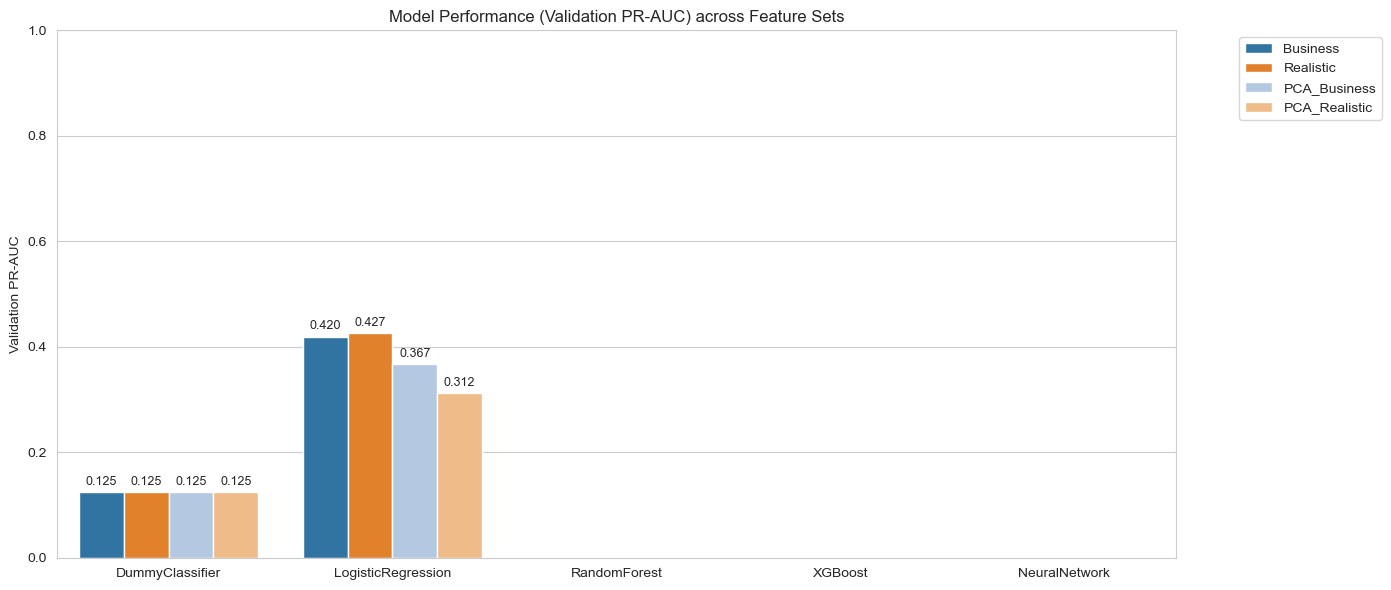

In [136]:
# Create Results DataFrame
results_df = pd.DataFrame(all_results)

if not results_df.empty:
    # Keep best run for each Model–Dataset combo (highest Val_PR_AUC)
    results_df = (
        results_df.sort_values("Val_PR_AUC", ascending=False)
                  .drop_duplicates(subset=["Model", "Dataset"], keep="first")
    )

    # Custom order
    model_order = ['DummyClassifier', 'LogisticRegression', 'RandomForest', 'XGBoost', 'NeuralNetwork']
    dataset_order = ['Business', 'Realistic', 'PCA_Business', 'PCA_Realistic']

    results_df["Model"] = pd.Categorical(results_df["Model"], categories=model_order, ordered=True)
    results_df["Dataset"] = pd.Categorical(results_df["Dataset"], categories=dataset_order, ordered=True)
    results_df = results_df.sort_values(["Model", "Dataset"])

    # Plot
    plt.figure(figsize=(14, 6))
    ax = sns.barplot(
        data=results_df,
        x="Model",
        y="Val_PR_AUC",
        hue="Dataset",
        palette=color_palette
    )

    plt.title("Model Performance (Validation PR-AUC) across Feature Sets")
    plt.ylim(0, 1.0)
    plt.ylabel("Validation PR-AUC")
    plt.xlabel("")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

    plt.tight_layout()
    plt.show()

---

## 4. Evaluation

In this section, we evaluate the performance of the 20 experimental model–feature set combinations (5 models × 4 feature sets) using the **held-out test set** to assess their generalization performance and practical usefulness for the business case of targeted insurance outreach.

> *Section 4.1 provides an overall performance overview based on test-set PR-AUC scores. Section 4.2 analyzes lift calculations for the best-performing models to quantify improvements over random targeting. Section 4.3 examines cumulative gain curves to assess how effectively the models rank individuals by their likelihood of being covered exclusively by Medicaid. Finally, Section 4.4 translates these results into a cost–benefit analysis to evaluate the potential business value of deploying the models in a real-world marketing scenario.*


### 4.1 Model Comparison (Test Performance)

After selecting and comparing models based on validation performance, we assess their **generalization ability** using the **held-out test set**, which has not been used during training or model selection. This step provides an unbiased estimate of how well each model–feature set combination is expected to perform on unseen data. Unlike Section 3.3, this section focuses exclusively on test-set performance and reflects final model quality.

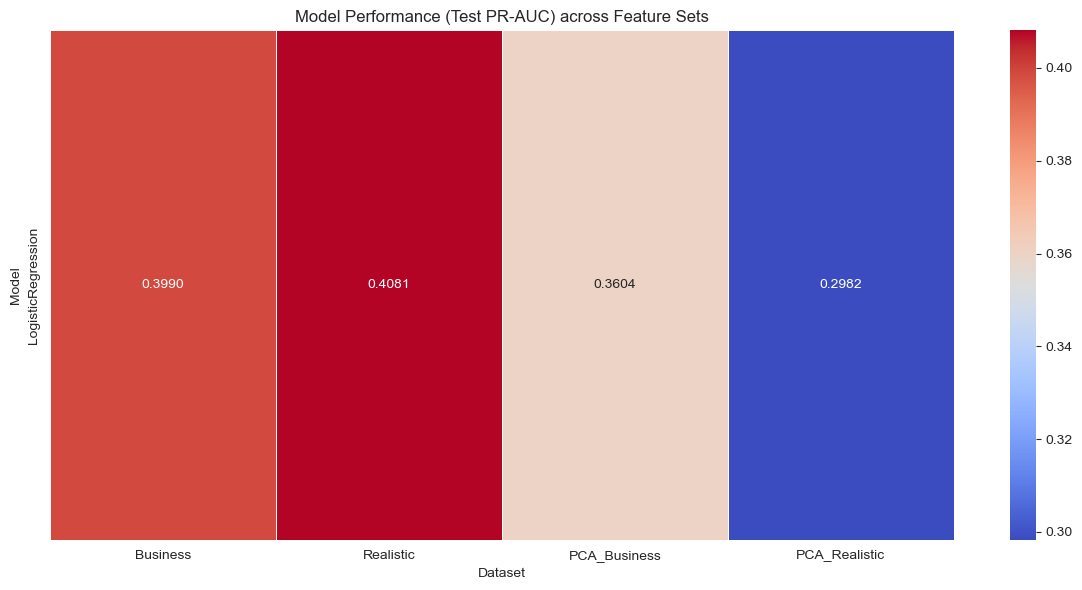

In [173]:
# Calculate Test Performance for all trained models
test_results = []

for res in all_results:
    if res['Model'] == 'Dummy Classifier':
        continue  # Skip baseline model for test evaluation

    X_test = data_splits[res['Dataset']]['X_test']
    y_test = data_splits[res['Dataset']]['y_test']
    model = res['Model_Instance']

    y_prob = (
        model.predict_proba(X_test)[:, 1]
        if hasattr(model, "predict_proba")
        else model.predict(X_test)
    )

    test_results.append({
        'Model': res['Model'],
        'Dataset': res['Dataset'],
        'Test_PR_AUC': average_precision_score(y_test, y_prob)
    })

# Create DataFrame and keep best run per Model–Dataset combination
results_df = (
    pd.DataFrame(test_results)
      .sort_values('Test_PR_AUC', ascending=False)
      .drop_duplicates(subset=['Model', 'Dataset'], keep='first')
)

# Define plotting order
model_order = ['LogisticRegression', 'RandomForest', 'XGBoost', 'NeuralNetwork']
dataset_order = ['Business', 'Realistic', 'PCA_Business', 'PCA_Realistic']

results_df['Model'] = pd.Categorical(results_df['Model'], categories=model_order, ordered=True)
results_df['Dataset'] = pd.Categorical(results_df['Dataset'], categories=dataset_order, ordered=True)

# Pivot for heatmap
pivot_table = results_df.pivot_table(
    index='Model',
    columns='Dataset',
    values='Test_PR_AUC'
)

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap='coolwarm', linewidths=.5)
plt.title('Model Performance (Test PR-AUC) across Feature Sets')
plt.tight_layout()
plt.show()

### 4.2 Best Model Lift Calculation

Next, we compute and visualize **cumulative lift curves** for the best-performing model of each feature set. Lift measures how much better a model performs compared to random targeting by showing how many times more Medicaid-only individuals are identified within the top-ranked share of the population. This metric is very relevant for the business case, as it directly quantifies the efficiency gains achievable when prioritizing outreach to a limited subset of individuals.

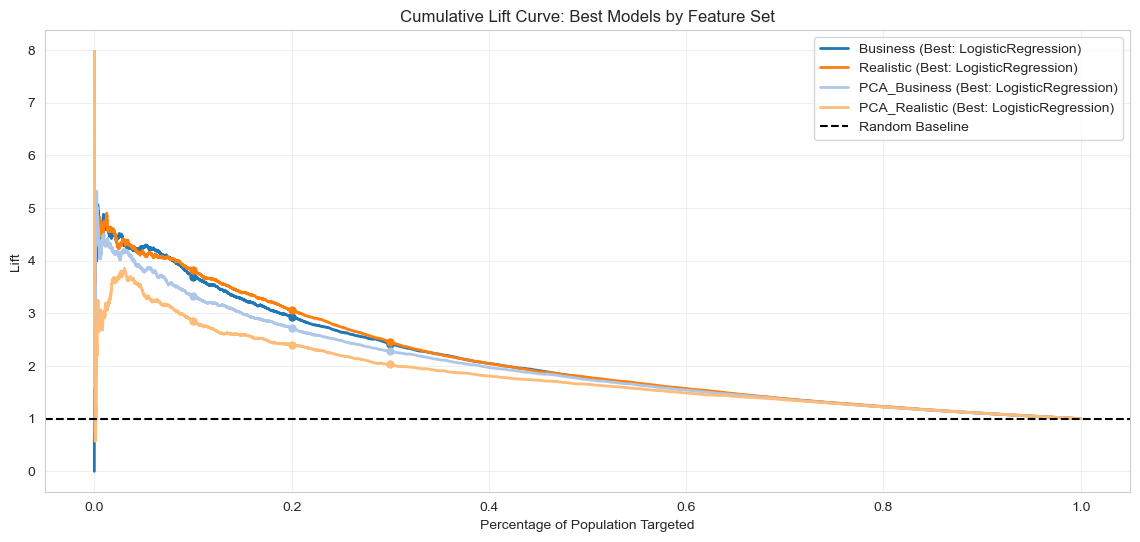

In [174]:
# Plot Cumulative Lift for Best Models per Dataset Type
if 'all_results' in locals() and all_results:
    plt.figure(figsize=(14, 6))
    
    # Define the datasets we want to compare
    target_datasets = [ 'Business', 'Realistic', 'PCA_Business', 'PCA_Realistic']
    colors = color_palette
    
    # Find best model for each target dataset based on PR-AUC
    best_models = {}
    for ds in target_datasets:
        ds_results = [r for r in all_results if r['Dataset'] == ds]
        if ds_results:
            # Sort by PR-AUC and pick top 1
            best_model_entry = sorted(ds_results, key=lambda x: x['Val_PR_AUC'], reverse=True)[0]
            best_models[ds] = best_model_entry

    # Plot curves
    for ds_name, entry in best_models.items():
        model_instance = entry['Model_Instance']
        model_name = entry['Model']
        
        # Ensure we use the correct key from the loop
        if ds_name in data_splits:
            X_test_curr = data_splits[ds_name]['X_test']
            y_test_curr = data_splits[ds_name]['y_test']
            
            if hasattr(model_instance, "predict_proba"):
                y_prob = model_instance.predict_proba(X_test_curr)[:, 1]
                y_true = np.array(y_test_curr)
                
                # Sort by predicted probability descending
                sorted_indices = np.argsort(y_prob)[::-1]
                sorted_y_true = y_true[sorted_indices]
                
                # Calculate Cumulative Gain
                cum_positives = np.cumsum(sorted_y_true)
                total_positives = cum_positives[-1]
                
                if total_positives > 0:
                    cum_gain = cum_positives / total_positives
                    # Percentage of population (x-axis)
                    x_axis = np.arange(1, len(cum_gain) + 1) / len(cum_gain)
                    
                    # Calculate Lift: Gain / % Population
                    lift = cum_gain / x_axis
                    
                    # Plot line
                    label_str = f"{ds_name} (Best: {model_name})"
                    plt.plot(x_axis, lift, label=label_str, color=colors.get(ds_name, 'gray'), linewidth=2)
                    
                    # Add markers at 10%, 20%, 30%
                    for pct in [0.1, 0.2, 0.3]:
                        idx = int(pct * len(lift)) - 1
                        plt.plot(x_axis[idx], lift[idx], marker='o', color=colors.get(ds_name, 'gray'), markersize=5)

    # Random Baseline (Lift = 1)
    plt.axhline(y=1, color='k', linestyle='--', label='Random Baseline')
    
    plt.title('Cumulative Lift Curve: Best Models by Feature Set')
    plt.xlabel('Percentage of Population Targeted')
    plt.ylabel('Lift')
    plt.legend()
    plt.grid(True, alpha=0.3)

### 4.3 Cumulative Gain

While PR-AUC summarizes overall classification quality, our business case is ultimately a *ranking problem*: given a limited outreach budget, we want to prioritize individuals who are most likely to be covered exclusively by Medicaid. To evaluate this ranking ability, we compute **cumulative gain** on the **test set** for each model–feature set combination.

For each model, we sort individuals by predicted probability of `only_medicaid` and calculate how many true positive cases are captured as we target the top 10%, 20%, and 30% of the ranked population (Gain@10%, Gain@20%, Gain@30%). These gain values are then summarized per model and feature set and visualized in a heatmap, enabling a direct comparison of how effectively different approaches concentrate the minority class in the highest-ranked segments.

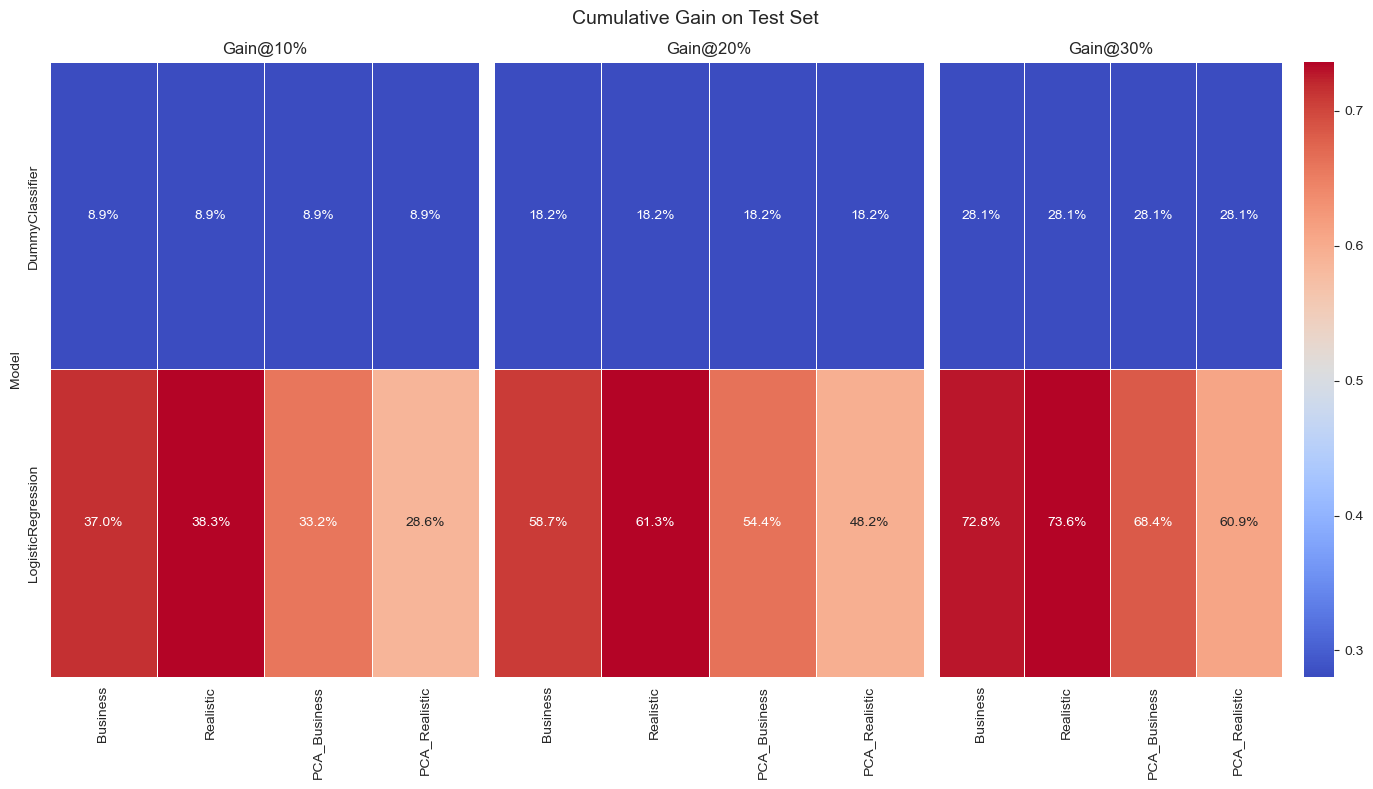

In [175]:
gain_rows = []

for res in all_results:
    model_name = res["Model"]
    dataset_name = res["Dataset"]
    model = res["Model_Instance"]

    X_test = data_splits[dataset_name]["X_test"]
    y_test = np.asarray(data_splits[dataset_name]["y_test"])

    # Predicted scores (probability if available, otherwise class prediction)
    y_score = (
        model.predict_proba(X_test)[:, 1]
        if hasattr(model, "predict_proba")
        else model.predict(X_test)
    )

    # Sort by predicted score descending
    sorted_idx = np.argsort(y_score)[::-1]
    sorted_y = y_test[sorted_idx]

    # Cumulative gain
    cum_pos = np.cumsum(sorted_y)
    total_pos = cum_pos[-1] if len(cum_pos) > 0 else 0
    if total_pos == 0:
        continue

    cum_gain = cum_pos / total_pos
    n = len(cum_gain)

    def gain_at(p):
        idx = max(0, int(p * n) - 1)
        return cum_gain[idx]

    gain_rows.append({
        "Model": model_name,
        "Dataset": dataset_name,
        "Gain@10%": gain_at(0.10),
        "Gain@20%": gain_at(0.20),
        "Gain@30%": gain_at(0.30),
    })

gain_df = pd.DataFrame(gain_rows)

# Keep best run per Model–Dataset pair (based on Gain@10%)
gain_df = (
    gain_df.sort_values("Gain@10%", ascending=False)
           .drop_duplicates(subset=["Model", "Dataset"], keep="first")
)

# Custom order (adjust if you removed Statistical sets earlier)
model_order = ["DummyClassifier", "LogisticRegression", "RandomForest", "XGBoost", "NeuralNetwork"]
dataset_order = ["Business", "Realistic", "PCA_Business", "PCA_Realistic"]

gain_df["Model"] = pd.Categorical(gain_df["Model"], categories=model_order, ordered=True)
gain_df["Dataset"] = pd.Categorical(gain_df["Dataset"], categories=dataset_order, ordered=True)


# Plot three heatmaps (10% / 20% / 30%)
fig, axes = plt.subplots(1, 3, figsize=(14, 8), sharey=True)

metrics = ["Gain@10%", "Gain@20%", "Gain@30%"]

for ax, metric in zip(axes, metrics):
    pivot = gain_df.pivot_table(
        index="Model",
        columns="Dataset",
        values=metric,
        aggfunc="mean"
    )

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".1%",
        cmap="coolwarm",
        linewidths=0.5,
        ax=ax,
        cbar=ax is axes[-1]  # show colorbar only once
    )

    ax.set_title(metric)
    ax.set_xlabel("")
    if ax is axes[0]:
        ax.set_ylabel("Model")
    else:
        ax.set_ylabel("")

plt.suptitle("Cumulative Gain on Test Set", fontsize=14)
plt.tight_layout()
plt.show()



To complement the cumulative gain heatmaps, we next visualize the **full cumulative gain curves** for the best-performing model of each feature set. These curves illustrate how effectively each model ranks individuals by likelihood of being covered exclusively by Medicaid across the entire population, and allow a direct comparison against a random targeting baseline.

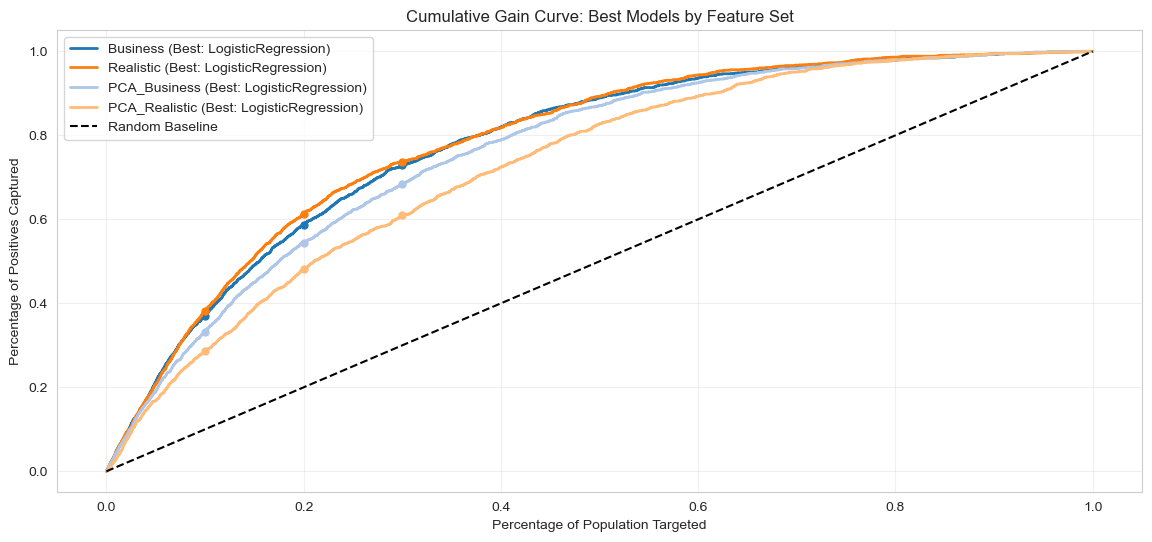

In [176]:
# Plot Cumulative Gain for Best Models per Dataset Type
if 'all_results' in locals() and all_results:
    plt.figure(figsize=(14, 6))
    
    # Define the datasets we want to compare
    target_datasets = [ 'Business', 'Realistic', 'PCA_Business', 'PCA_Realistic']
    colors = color_palette
    
    # Find best model for each target dataset based on PR-AUC
    best_models = {}
    for ds in target_datasets:
        ds_results = [r for r in all_results if r['Dataset'] == ds]
        if ds_results:
            # Sort by PR-AUC and pick top 1
            best_model_entry = sorted(ds_results, key=lambda x: x['Val_PR_AUC'], reverse=True)[0]
            best_models[ds] = best_model_entry

    # Plot curves
    for ds_name, entry in best_models.items():
        model_instance = entry['Model_Instance']
        model_name = entry['Model']
        
        if dataset_name in data_splits:
            X_test_curr = data_splits[ds_name]['X_test']
            y_test_curr = data_splits[ds_name]['y_test']
            
            if hasattr(model_instance, "predict_proba"):
                y_prob = model_instance.predict_proba(X_test_curr)[:, 1]
                y_true = np.array(y_test_curr)
                
                # Sort
                sorted_indices = np.argsort(y_prob)[::-1]
                sorted_y_true = y_true[sorted_indices]
                
                # Cumulative Gain
                cum_positives = np.cumsum(sorted_y_true)
                total_positives = cum_positives[-1]
                
                if total_positives > 0:
                    cum_gain = cum_positives / total_positives
                    x_axis = np.arange(1, len(cum_gain) + 1) / len(cum_gain)
                    
                    # Plot line
                    label_str = f"{ds_name} (Best: {model_name})"
                    plt.plot(x_axis, cum_gain, label=label_str, color=colors.get(ds_name, 'gray'), linewidth=2)
                    
                    # Add markers at 10%, 20%, 30%
                    for pct in [0.1, 0.2, 0.3]:
                        idx = int(pct * len(cum_gain)) - 1
                        plt.plot(x_axis[idx], cum_gain[idx], marker='o', color=colors.get(ds_name, 'gray'), markersize=5)

    # Random Baseline
    plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
    
    plt.title('Cumulative Gain Curve: Best Models by Feature Set')
    plt.xlabel('Percentage of Population Targeted')
    plt.ylabel('Percentage of Positives Captured')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No results found.")

### 4.4 Cost–Benefit Analysis

To assess the practical business value of our models, we perform a **break-even analysis** that compares the **cost of outreach** against the **expected benefit** from acquiring a new customer. The objective is to quantify how strong the model’s targeting performance (i.e., lift or precision among contacted individuals) must be for outreach efforts to become profitable.

**Scenario parameters (assumptions):**
- **Customer lifetime value:**  
  - Profit per year: **$34**  
  - Assumed customer lifetime: **10 years**  
  - **Total profit per sale:** **$340**
- **Conversion rate when contacting the “right person” (true positive):**  
  - **3%** probability of a successful sale
- **Outreach (cold call) effort:**  
  - Average call duration: **2:52**  
  - Calls per hour: **21**
- **Cost of outreach:**  
  - Hourly wage of outreach agent: **$30**  
  - **Cost per contact:** **$1.43**
- **Fixed data cost:**  
  - Cost per record (e.g., data broker fee): **$0.05** per individual
- **Online advertisement cost (reference):**  
  - **$30–$40** per acquisition (used as a benchmark)
- **Derived metrics:**
  - Expected benefit per correctly identified individual: **$10.20**
  - Required precision to break even: **14.01%**

Using these assumptions, we compute the expected benefit of contacting correctly identified individuals and determine the **minimum required precision (break-even point)** for profitable outreach. We then compare the profitability of different feature sets (Business, Realistic, and their PCA variants) by applying this analysis to model predictions on the test data.


Business Max Profit: $6576.81 at 4091 contacts (28.5% of population)
Realistic Max Profit: $6783.59 at 3882 contacts (27.1% of population)
PCA_Business Max Profit: $5809.07 at 4607 contacts (32.1% of population)
PCA_Realistic Max Profit: $4457.73 at 5403 contacts (37.7% of population)


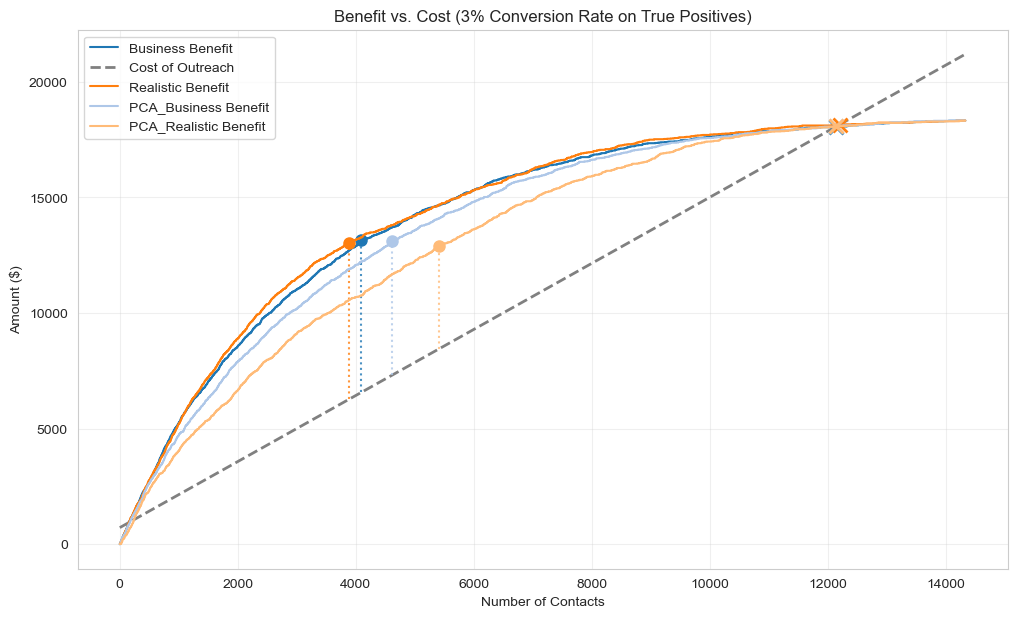

In [179]:
# Constants from the problem description
profit_per_sale = 34 * 10 # $170 Lifetime Value
conversion_rate_right_person = 0.03 # 3% chance of sale if we contact the "Right Person" (True Positive)
calls_per_hour = 21
hourly_wage = 30
cost_per_record = 0.05
    

# Calculate Cost and Benefit per unit
cost_per_contact = hourly_wage / calls_per_hour
# Expected benefit of finding a "Right Person" = Value of Sale * Probability of Sale
expected_benefit_per_right_person = profit_per_sale * conversion_rate_right_person

required_precision = cost_per_contact / expected_benefit_per_right_person

fix_cost_dataset = cost_per_record * X_test.shape[0] 

#print(f"--- Cost-Benefit Analysis Parameters ---")
#print(f"Hourly Wage: ${hourly_wage:.2f}")
#print(f"Cost per Contact: ${cost_per_contact:.2f}")
#print(f"Value per Sale: ${profit_per_sale:.2f}")
#print(f"Conversion Rate (Given Right Person): {conversion_rate_right_person:.1%}")
#print(f"Expected Benefit per 'Right Person' Contacted: ${expected_benefit_per_right_person:.2f}")
#print(f"Required Precision to Break Even: {required_precision:.2%}")
#print(f"----------------------------------------")

# Plot Benefit vs Cost Curves
plt.figure(figsize=(12, 7))

target_datasets = ['Business', 'Realistic', 'PCA_Business', 'PCA_Realistic']
colors = color_palette

cost_plotted = False

for ds_name in target_datasets:
    if 'best_models' in locals() and ds_name in best_models and ds_name in data_splits:
        entry = best_models[ds_name]
        model = entry['Model_Instance']
        
        X_test_curr = data_splits[ds_name]['X_test']
        y_test_curr = data_splits[ds_name]['y_test']
        
        if hasattr(model, "predict_proba"):
            # Get probabilities
            y_prob = model.predict_proba(X_test_curr)[:, 1]
            y_true = np.array(y_test_curr)
            
            # Sort by probability (Model Ranking)
            sorted_indices = np.argsort(y_prob)[::-1]
            sorted_y_true = y_true[sorted_indices]
            
            # Calculate Cumulative Benefit
            # Benefit accumulates only when we find a "Right Person" (y_true=1)
            # Value = Count of True Positives * Expected Benefit per Right Person
            cum_true_positives = np.cumsum(sorted_y_true)
            benefit = cum_true_positives * expected_benefit_per_right_person
            
            # Calculate Cumulative Cost
            # Cost accumulates for every person contacted
            n = len(y_true)
            cum_contacted = np.arange(1, n + 1)
            cost = cum_contacted * cost_per_contact + fix_cost_dataset
            
            # X-axis: Number of contacts
            x_axis = cum_contacted

            
            # Plot Benefit Curve
            p = plt.plot(x_axis, benefit, label=f"{ds_name} Benefit", color=colors.get(ds_name, 'gray'))
            
            # Plot Cost Curve (only once)
            if not cost_plotted:
                plt.plot(x_axis, cost, label='Cost of Outreach', color='grey', linestyle='--', linewidth=2)
                cost_plotted = True
            
            # Find Break-even point (Intersection of Benefit and Cost)
            profit = benefit - cost
            
            # --- Added: Max Profit Point ---
            max_profit_idx = np.argmax(profit)
            max_profit_val = profit[max_profit_idx]
            
            # Plot Max Profit Point
            plt.plot(x_axis[max_profit_idx], benefit[max_profit_idx], 'o', 
                     color=colors.get(ds_name, 'gray'), markersize=8)
            
            # Draw a vertical line to show the max distance
            plt.vlines(x=x_axis[max_profit_idx], ymin=cost[max_profit_idx], ymax=benefit[max_profit_idx], 
                       colors=colors.get(ds_name, 'gray'), linestyles='dotted', alpha=0.8)
            
            # Annotate Max Profit
            plt.annotate(f"", 
                         (x_axis[max_profit_idx], benefit[max_profit_idx]),
                         textcoords="offset points", xytext=(-20, 10), ha='right', color=colors.get(ds_name, 'gray'))
            
            print(f"{ds_name} Max Profit: ${max_profit_val:.2f} at {x_axis[max_profit_idx]} contacts ({x_axis[max_profit_idx]/n:.1%} of population)")
            
            # -------------------------------            
            profitable_mask = profit > 0
            if np.any(profitable_mask):
                last_profitable_idx = np.where(profitable_mask)[0][-1]
                
                # Mark the break-even point
                plt.plot(x_axis[last_profitable_idx], benefit[last_profitable_idx], 'x', 
                         color=colors.get(ds_name, 'gray'), markersize=10, markeredgewidth=2)
                
plt.title(f'Benefit vs. Cost (3% Conversion Rate on True Positives)')
plt.xlabel('Number of Contacts')
plt.ylabel('Amount ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

# 5. Fairness

In [178]:
# Define mappings for better readability (Standard ACS PUMS codes)
mappings = {
    "SEX": {1: "Male", 2: "Female"},
    "RAC1P": {
        1: "White", 
        2: "Black", 
        3: "Amer. Indian", 
        4: "Alaska Native",
        5: "Amer. Indian/Alaska", 
        6: "Asian", 
        7: "Native Hawaiian",
        8: "Other Pacific Isl.", 
        9: "Two or More"
    }
}

# Attempt to identify the best model and dataset from all_results if available
if 'all_results' in locals() and all_results:
    # Find the single best model based on Validation PR-AUC
    best_entry = sorted(all_results, key=lambda x: x.get('Val_PR_AUC', 0), reverse=True)[0]
    best_model = best_entry['Model_Instance']
    best_dataset_name = best_entry['Dataset']
    print(f"Identified Best Model: {best_entry['Model']} on Dataset: {best_dataset_name} (Val PR-AUC: {best_entry.get('Val_PR_AUC', 0):.4f})")
elif 'best_model' in locals():
    print("Using pre-defined 'best_model'. Ensure 'best_dataset_name' is set correctly if it relies on specific features.")
else:
    print("No model found. Please run model training.")

# Ensure we have the metrics from the previous step
if 'best_model' in locals() and 'data_splits' in locals() and 'df_2_3' in locals():
    
    # Determine which X_test to use
    if 'best_dataset_name' in locals() and best_dataset_name in data_splits:
        X_test_eval = data_splits[best_dataset_name]['X_test']
        y_test_eval = data_splits[best_dataset_name]['y_test']
        print(f"Using dataset features from: {best_dataset_name}")
    elif 'X_test' in locals() and 'y_test' in locals():
        print("Warning: best_dataset_name not found. Using global X_test/y_test.")
        X_test_eval = X_test
        y_test_eval = y_test
    else:
        print("Error: Could not determine X_test/y_test.")
        X_test_eval = None

    if X_test_eval is not None:
        # Calculate predictions once
        if hasattr(best_model, "predict_proba"):
            try:
                y_prob = best_model.predict_proba(X_test_eval)[:, 1]
                y_pred = (y_prob >= 0.5).astype(int)
            except ValueError as e:
                print(f"Prediction failed: {e}")
                y_pred = None
        else:
            y_pred = best_model.predict(X_test_eval)

        if y_pred is not None:
            # 1. Collect all metrics into a single DataFrame for plotting
            fairness_summary = []
            
            for attr in attributes_to_check:
                if attr in df_2_3.columns:
                    # Use X_test_eval.index to align with the test set
                    sensitive_series = df_2_3.loc[X_test_eval.index, attr]
                    
                    # Apply mapping if available
                    if attr in mappings:
                        sensitive_series = sensitive_series.map(mappings[attr]).fillna(sensitive_series)
                    
                    # Get group-level metrics
                    metrics = MetricFrame(
                        metrics={
                            "Selection Rate": selection_rate,
                            "TPR (Recall)": true_positive_rate,
                            "Base Rate": lambda y_true, y_pred: np.mean(y_true)
                        },
                        y_true=y_test_eval,
                        y_pred=y_pred,
                        sensitive_features=sensitive_series,
                    )
                    
                    # Store group data
                    group_df = metrics.by_group.reset_index()
                    group_df['Attribute'] = attr
                    # Rename the sensitive attribute column to 'Group' for consistent plotting
                    group_df.rename(columns={attr: 'Group'}, inplace=True)
                    fairness_summary.append(group_df)

            # Combine all data
            if fairness_summary:
                plot_data = pd.concat(fairness_summary, ignore_index=True)
                
                # 2. Plot Selection Rate, TPR & Base Rate for each Attribute
                for attr in attributes_to_check:
                    subset = plot_data[plot_data['Attribute'] == attr].copy()
                    
                    if not subset.empty:
                        # Re-get sensitive series for metric calculation
                        sensitive_series = df_2_3.loc[X_test_eval.index, attr]
                        if attr in mappings:
                            sensitive_series = sensitive_series.map(mappings[attr]).fillna(sensitive_series)

                        # Calculate aggregate fairness metrics
                        dp_diff = demographic_parity_difference(y_test_eval, y_pred, sensitive_features=sensitive_series)
                        eo_diff = equalized_odds_difference(y_test_eval, y_pred, sensitive_features=sensitive_series)

                        # Melt for side-by-side bars
                        subset_melt = subset.melt(id_vars=['Group'], 
                                                  value_vars=['Base Rate', 'Selection Rate', 'TPR (Recall)'], 
                                                  var_name='Metric', value_name='Value')
                        
                        plt.figure(figsize=(12, 6))
                        sns.barplot(data=subset_melt, x='Group', y='Value', hue='Metric', palette="viridis", hue_order=['Base Rate', 'Selection Rate', 'TPR (Recall)'])
                        plt.title(f"Fairness Check: {attr} (Base Rate vs. Selection Rate vs. TPR)")
                        plt.ylabel("Rate (0-1)")
                        plt.ylim(0, 1.1)
                        
                        # Calculate average selection rate for the reference line
                        avg_selection = subset['Selection Rate'].mean()
                        plt.axhline(y=avg_selection, color='b', linestyle='--', alpha=0.5, label='Avg Selection')
                        
                        plt.legend(loc='upper right')
                        plt.grid(axis='y', alpha=0.3)
                        plt.show()
                        
                        print(f"Fairness Metrics for {attr}:")
                        print(f"  Demographic Parity Difference: {dp_diff:.4f}")
                        print(f"  Equalized Odds Difference:     {eo_diff:.4f}")

else:
    print("Please run the previous fairness assessment cell first.")

Identified Best Model: LogisticRegression on Dataset: Realistic (Val PR-AUC: 0.4269)
Using dataset features from: Realistic


NameError: name 'attributes_to_check' is not defined